# Credit Card Transaction Fraud Detection

Binary classification project to detect fraudulent transactions in a highly
imbalanced financial transactions dataset (6.36M rows, ~0.13% fraud).

**Pipeline:** EDA -> feature engineering -> train/test split -> model
comparison (Logistic Regression, Random Forest, XGBoost) -> feature
importance -> SHAP explainability -> a simple fraud-scoring function.

**Dataset columns:** `step` (time unit, 1 hour), `type` (transaction type),
`amount`, `nameOrig`/`nameDest` (account IDs), `oldbalanceOrg`/`newbalanceOrig`,
`oldbalanceDest`/`newbalanceDest`, `isFraud` (target), `isFlaggedFraud`
(dataset's own rule-based flag).

In [1]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


## 1. Data Loading & Initial Inspection

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("credit card transactions.csv")

df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [4]:
df.shape

(6362620, 11)

In [5]:
df.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='str')

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            str    
 2   amount          float64
 3   nameOrig        str    
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        str    
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), str(3)
memory usage: 706.2 MB


In [7]:
df.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

## 2. Exploratory Data Analysis (EDA)

In [9]:
df["isFraud"].value_counts()

isFraud
0    6354407
1       8213
Name: count, dtype: int64

In [10]:
df["isFraud"].value_counts(normalize=True)*100

isFraud
0    99.870918
1     0.129082
Name: proportion, dtype: float64

In [11]:
df["type"].value_counts()

type
CASH_OUT    2237500
PAYMENT     2151495
CASH_IN     1399284
TRANSFER     532909
DEBIT         41432
Name: count, dtype: int64

In [12]:
pd.crosstab(
    df["type"],
    df["isFraud"],
    margins=True
)

isFraud,0,1,All
type,,,
CASH_IN,1399284,0,1399284
CASH_OUT,2233384,4116,2237500
DEBIT,41432,0,41432
PAYMENT,2151495,0,2151495
TRANSFER,528812,4097,532909
All,6354407,8213,6362620


In [13]:
fraud_by_type = (
    df.groupby("type")["isFraud"]
    .mean()
    .sort_values(ascending=False)*100
)

fraud_by_type

type
TRANSFER    0.768799
CASH_OUT    0.183955
CASH_IN     0.000000
DEBIT       0.000000
PAYMENT     0.000000
Name: isFraud, dtype: float64

In [14]:
fraud_counts = df["isFraud"].value_counts()

print ("Legitimate transaction :" , fraud_counts[0])
print ("Fraudulent transaction :" , fraud_counts[1])


print("\nFraud percentage: ")
print (df["isFraud"].mean() * 100 )

Legitimate transaction : 6354407
Fraudulent transaction : 8213

Fraud percentage: 
0.12908204481801522


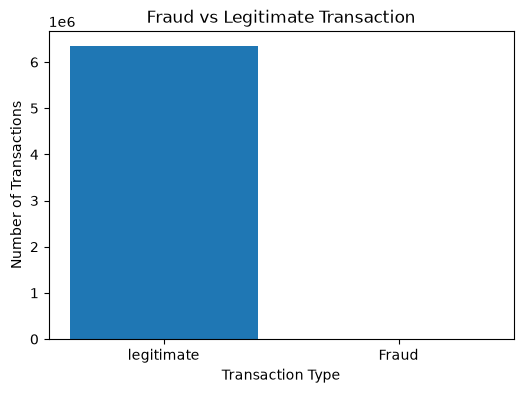

In [15]:
fraud_counts = df["isFraud"].value_counts()

plt.figure(figsize=(6,4))
plt.bar(
    ["legitimate","Fraud"],
    fraud_counts.values
)

plt.title("Fraud vs Legitimate Transaction")
plt.xlabel("Transaction Type")
plt.ylabel("Number of Transactions")

plt.show()


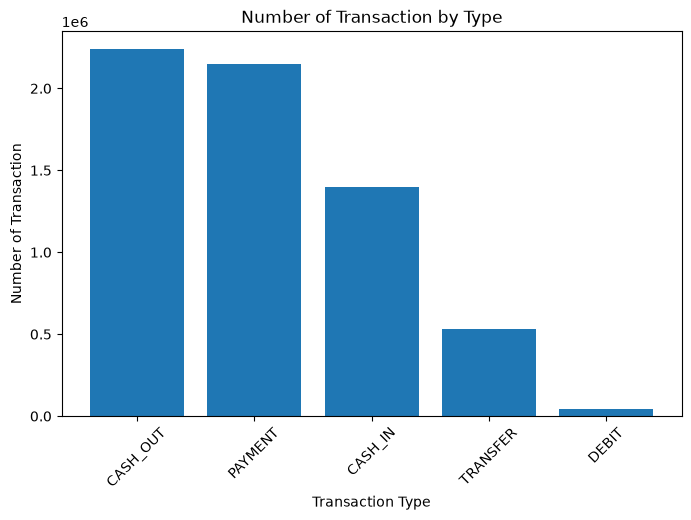

In [16]:
type_counts = df["type"].value_counts()

plt.figure(figsize=(8,5))

plt.bar(
    type_counts.index,
    type_counts.values
)

plt.title("Number of Transaction by Type")
plt.xlabel("Transaction Type")
plt.ylabel("Number of Transaction")

plt.xticks(rotation=45)

plt.show()

In [17]:
fraud_type = pd.crosstab(
    df["type"],
    df["isFraud"]
)

fraud_type

isFraud,0,1
type,,
CASH_IN,1399284,0
CASH_OUT,2233384,4116
DEBIT,41432,0
PAYMENT,2151495,0
TRANSFER,528812,4097


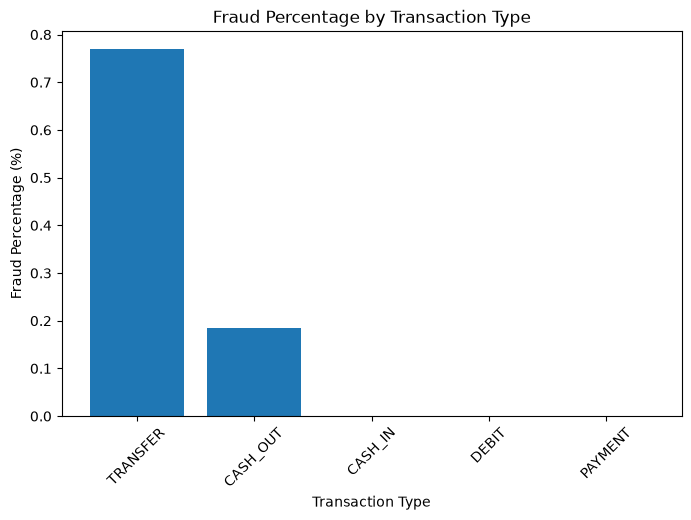

In [18]:
plt.figure(figsize=(8,5))

plt.bar(
    fraud_by_type.index,
    fraud_by_type.values
)

plt.title("Fraud Percentage by Transaction Type")
plt.xlabel("Transaction Type")
plt.ylabel("Fraud Percentage (%)")

plt.xticks(rotation=45)

plt.show()



In [19]:
df["amount"].describe()

count    6.362620e+06
mean     1.798619e+05
std      6.038582e+05
min      0.000000e+00
25%      1.338957e+04
50%      7.487194e+04
75%      2.087215e+05
max      9.244552e+07
Name: amount, dtype: float64

In [20]:
df.groupby("isFraud")["amount"].describe()

,count,mean,std,min,25%,50%,75%,max
isFraud,,,,,,,,
0,6354407.0,1.781970e+05,5.962370e+05,0.01,13368.395,74684.72,208364.76,92445516.64
1,8213.0,1.467967e+06,2.404253e+06,0.00,127091.330,441423.44,1517771.48,10000000.00


In [21]:
amount_comparison = df.groupby("isFraud")["amount"].agg(
    ["count", "mean", "median", "min", "max"]
)

amount_comparison

,count,mean,median,min,max
isFraud,,,,,
0,6354407,1.781970e+05,74684.72,0.01,92445516.64
1,8213,1.467967e+06,441423.44,0.00,10000000.00


In [22]:
amount_sample = df.sample(
    n=200000,
    random_state=42
)

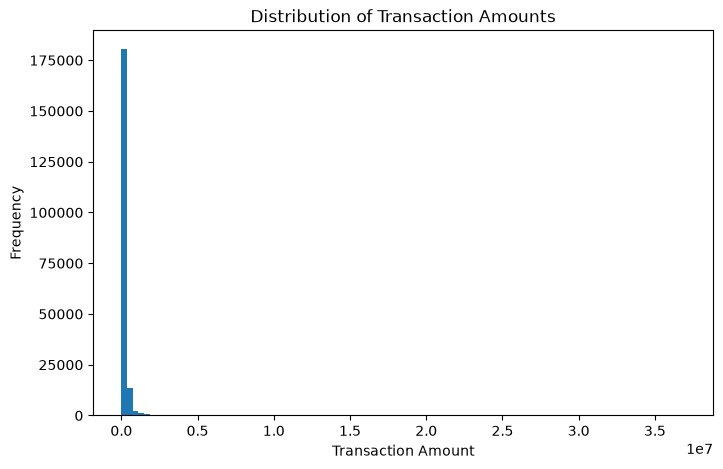

In [23]:
plt.figure(figsize=(8, 5))

plt.hist(
    amount_sample["amount"],
    bins=100
)

plt.title("Distribution of Transaction Amounts")
plt.xlabel("Transaction Amount")
plt.ylabel("Frequency")

plt.show()

In [24]:
legitimate_amounts = df.loc[
    df["isFraud"] == 0,
    "amount"
]

fraud_amounts = df.loc[
    df["isFraud"] == 1,
    "amount"
]

In [25]:
print("Average legitimate transaction:",
      legitimate_amounts.mean())

print("Average fraudulent transaction:",
      fraud_amounts.mean())

print("Median legitimate transaction:",
      legitimate_amounts.median())

print("Median fraudulent transaction:",
      fraud_amounts.median())

Average legitimate transaction: 178197.0417274075
Average fraudulent transaction: 1467967.2991403872
Median legitimate transaction: 74684.72
Median fraudulent transaction: 441423.44


In [26]:
print("Minimum step:", df["step"].min())
print("Maximum step:", df["step"].max())

Minimum step: 1
Maximum step: 743


In [27]:
transactions_by_step = df.groupby("step").size()

transactions_by_step.head()

step
1    2708
2    1014
3     552
4     565
5     665
dtype: int64

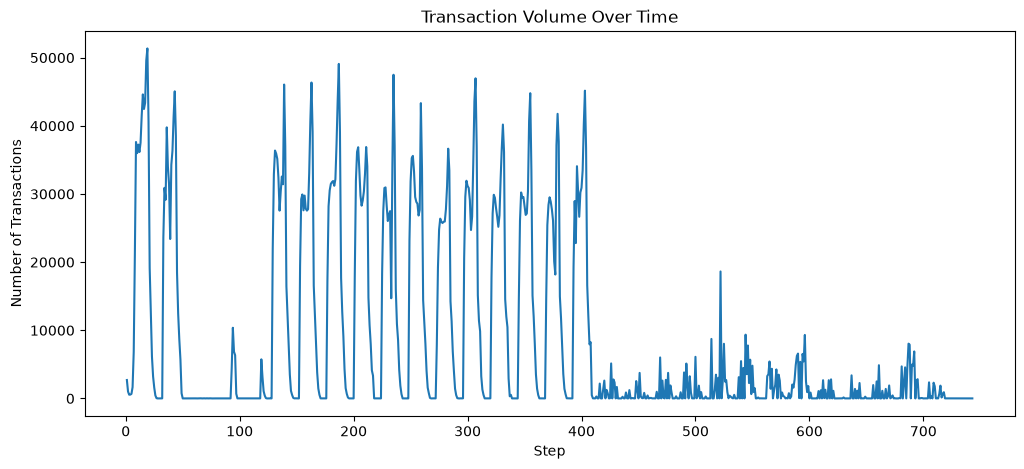

In [28]:
plt.figure(figsize=(12, 5))

plt.plot(
    transactions_by_step.index,
    transactions_by_step.values
)

plt.title("Transaction Volume Over Time")
plt.xlabel("Step")
plt.ylabel("Number of Transactions")

plt.show()

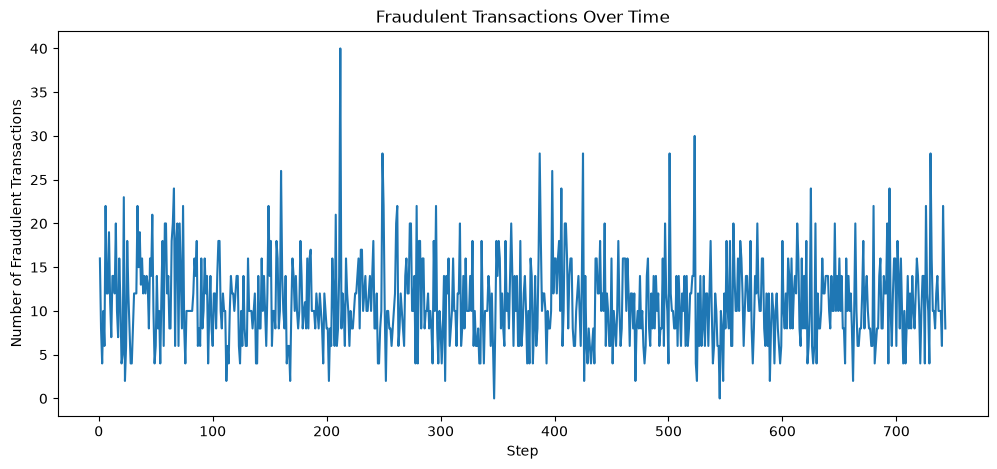

In [29]:
fraud_by_step = df.groupby("step")["isFraud"].sum()

plt.figure(figsize=(12, 5))

plt.plot(
    fraud_by_step.index,
    fraud_by_step.values
)

plt.title("Fraudulent Transactions Over Time")
plt.xlabel("Step")
plt.ylabel("Number of Fraudulent Transactions")

plt.show()

In [30]:
fraud_rate_by_step = (
    df.groupby("step")["isFraud"]
      .mean()
      .mul(100)
)

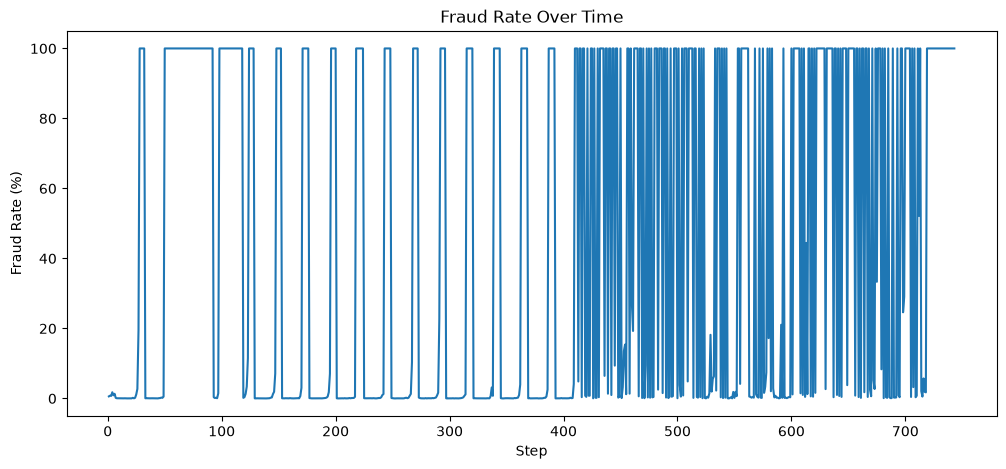

In [31]:
plt.figure(figsize=(12, 5))

plt.plot(
    fraud_rate_by_step.index,
    fraud_rate_by_step.values
)

plt.title("Fraud Rate Over Time")
plt.xlabel("Step")
plt.ylabel("Fraud Rate (%)")

plt.show()

In [32]:
fraud_transactions_by_type = (
    df[df["isFraud"] == 1]
    .groupby("type")
    .size()
    .sort_values(ascending=False)
)

fraud_transactions_by_type

type
CASH_OUT    4116
TRANSFER    4097
dtype: int64

In [33]:
eda_summary = df.groupby("type").agg(
    Total_Transactions=("isFraud", "size"),
    Fraud_Transactions=("isFraud", "sum"),
    Fraud_Rate=("isFraud", "mean"),
    Average_Amount=("amount", "mean"),
    Median_Amount=("amount", "median")
)

eda_summary["Fraud_Rate"] = (
    eda_summary["Fraud_Rate"] * 100
)

eda_summary.sort_values(
    "Fraud_Rate",
    ascending=False
)

,Total_Transactions,Fraud_Transactions,Fraud_Rate,Average_Amount,Median_Amount
type,,,,,
TRANSFER,532909,4097,0.768799,910647.009645,486308.390
CASH_OUT,2237500,4116,0.183955,176273.964346,147072.185
CASH_IN,1399284,0,0.000000,168920.242004,143427.710
DEBIT,41432,0,0.000000,5483.665314,3048.990
PAYMENT,2151495,0,0.000000,13057.604660,9482.190


### Key EDA findings

- Fraud is extremely rare: **8,213 of 6,362,620 transactions (0.13%)**.
- Fraud only ever occurs in two transaction types: **`TRANSFER`** (0.77% fraud rate)
  and **`CASH_OUT`** (0.18% fraud rate). `PAYMENT`, `CASH_IN`, and `DEBIT` have
  **zero** fraud cases in this dataset.
- The dataset's own `isFlaggedFraud` rule catches only **16 of 8,213** fraud
  cases (~0.2% recall) — it is not a usable signal on its own.
- Fraudulent transactions move much more money: mean **$1.47M** vs **$178K**
  for legitimate ones (median **$441K** vs **$75K**), roughly 6-8x larger.

## 3. Data Cleaning & Feature Engineering

In [34]:
df_clean = df.copy()

In [35]:
df_clean.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

In [36]:
df_clean.duplicated().sum()

np.int64(0)

In [37]:
df_clean = df_clean.drop_duplicates()

In [38]:
df_clean.duplicated().sum()

np.int64(0)

In [39]:
df_clean.dtypes

step                int64
type                  str
amount            float64
nameOrig              str
oldbalanceOrg     float64
newbalanceOrig    float64
nameDest              str
oldbalanceDest    float64
newbalanceDest    float64
isFraud             int64
isFlaggedFraud      int64
dtype: object

In [40]:
numeric_columns = [
    "step",
    "amount",
    "oldbalanceOrg",
    "newbalanceOrig",
    "oldbalanceDest",
    "newbalanceDest"
]

(df_clean[numeric_columns] < 0).sum()

step              0
amount            0
oldbalanceOrg     0
newbalanceOrig    0
oldbalanceDest    0
newbalanceDest    0
dtype: int64

In [41]:
(df_clean["amount"] == 0).sum()

np.int64(16)

In [42]:
df_clean[df_clean["amount"] == 0]["isFraud"].value_counts()

isFraud
1    16
Name: count, dtype: int64

In [43]:
df_clean["isFlaggedFraud"].value_counts()

isFlaggedFraud
0    6362604
1         16
Name: count, dtype: int64

In [44]:
pd.crosstab(
    df_clean["isFlaggedFraud"],
    df_clean["isFraud"],
    margins=True
)

isFraud,0,1,All
isFlaggedFraud,,,
0,6354407,8197,6362604
1,0,16,16
All,6354407,8213,6362620


In [45]:
origin_transaction_count = (
    df_clean["nameOrig"]
    .value_counts()
)

In [46]:
df_clean["origin_transaction_count"] = (
    df_clean["nameOrig"]
    .map(origin_transaction_count)
)

In [47]:
df_clean[
    ["nameOrig", "origin_transaction_count"]
].head()

,nameOrig,origin_transaction_count
0,C1231006815,1
1,C1666544295,1
2,C1305486145,1
3,C840083671,1
4,C2048537720,1


In [48]:
destination_transaction_count = (
    df_clean["nameDest"]
    .value_counts()
)

df_clean["destination_transaction_count"] = (
    df_clean["nameDest"]
    .map(destination_transaction_count)
)

In [49]:
df_clean[
    ["nameDest", "destination_transaction_count"]
].head()

,nameDest,destination_transaction_count
0,M1979787155,1
1,M2044282225,1
2,C553264065,44
3,C38997010,41
4,M1230701703,1


In [50]:
df_clean["log_amount"] = np.log1p(df_clean["amount"])

In [51]:
df_clean[
    ["amount", "log_amount"]
].head()


,amount,log_amount
0,9839.64,9.194276
1,1864.28,7.531166
2,181.00,5.204007
3,181.00,5.204007
4,11668.14,9.364703


In [52]:
df_clean["origin_balance_change"] = (
    df_clean["oldbalanceOrg"] -
    df_clean["newbalanceOrig"]
)

In [53]:
df_clean["destination_balance_change"] = (
    df_clean["newbalanceDest"] -
    df_clean["oldbalanceDest"]
)

In [54]:
df_clean["origin_amount_difference"] = (
    df_clean["origin_balance_change"] -
    df_clean["amount"]
)

In [55]:
df_clean["destination_amount_difference"] = (
    df_clean["destination_balance_change"] -
    df_clean["amount"]
)

In [56]:
df_clean["hour"] = df_clean["step"] % 24

In [57]:
df_clean["hour"].value_counts().sort_index()

hour
0      71587
1      27111
2       9018
3       2007
4       1241
5       1641
6       3420
7       8988
8      26915
9     283518
10    425729
11    445992
12    483418
13    468474
14    439653
15    416686
16    441612
17    439941
18    580509
19    647814
20    553728
21    247806
22    194555
23    141257
Name: count, dtype: int64

In [58]:
df_clean["day"] = df_clean["step"] // 24

In [59]:
df_clean["day"].value_counts().sort_index()

day
0     571039
1     452761
2       6749
3      21904
4      12995
5     440626
6     420282
7     449147
8     418103
9     392886
10    418006
11    349800
12    429335
13    398210
14    400706
15    375514
16    421098
17     29251
18     11286
19     19739
20     24589
21     52510
22     50432
23     33349
24     58712
25     13893
26      8574
27     14522
28     55037
29     11283
30       282
Name: count, dtype: int64

In [60]:
features = [
    "step",
    "amount",
    "type",
    "hour",
    "day",
    "origin_transaction_count",
    "destination_transaction_count",
    "log_amount",
    "origin_balance_change",
    "destination_balance_change",
    "origin_amount_difference",
    "destination_amount_difference"
]

In [61]:
X = df_clean[features]

y = df_clean["isFraud"]

X.head()


,step,amount,type,hour,day,origin_transaction_count,destination_transaction_count,log_amount,origin_balance_change,destination_balance_change,origin_amount_difference,destination_amount_difference
0,1,9839.64,PAYMENT,1,0,1,1,9.194276,9839.64,0.0,1.455192e-11,-9839.64
1,1,1864.28,PAYMENT,1,0,1,1,7.531166,1864.28,0.0,-1.136868e-12,-1864.28
2,1,181.00,TRANSFER,1,0,1,44,5.204007,181.00,0.0,0.000000e+00,-181.00
3,1,181.00,CASH_OUT,1,0,1,41,5.204007,181.00,-21182.0,0.000000e+00,-21363.00
4,1,11668.14,PAYMENT,1,0,1,1,9.364703,11668.14,0.0,0.000000e+00,-11668.14


In [62]:
y.head()

0    0
1    0
2    1
3    1
4    0
Name: isFraud, dtype: int64

In [63]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (6362620, 12)
y shape: (6362620,)


In [64]:
print("\nFeatures:")
print(X.columns.tolist())


Features:
['step', 'amount', 'type', 'hour', 'day', 'origin_transaction_count', 'destination_transaction_count', 'log_amount', 'origin_balance_change', 'destination_balance_change', 'origin_amount_difference', 'destination_amount_difference']


In [65]:
print("\nTarget distribution:")
print(y.value_counts())


Target distribution:
isFraud
0    6354407
1       8213
Name: count, dtype: int64


In [66]:
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 12 columns):
 #   Column                         Dtype  
---  ------                         -----  
 0   step                           int64  
 1   amount                         float64
 2   type                           str    
 3   hour                           int64  
 4   day                            int64  
 5   origin_transaction_count       int64  
 6   destination_transaction_count  int64  
 7   log_amount                     float64
 8   origin_balance_change          float64
 9   destination_balance_change     float64
 10  origin_amount_difference       float64
 11  destination_amount_difference  float64
dtypes: float64(6), int64(5), str(1)
memory usage: 627.6 MB


In [67]:
features = [
    "step",
    "amount",
    "type",
    "hour",
    "day",
    "origin_transaction_count",
    "destination_transaction_count",
    "log_amount"
]

X = df_clean[features]
y = df_clean["isFraud"]

In [68]:
print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nFeatures:")
print(X.columns.tolist())

print("\nTarget distribution:")
print(y.value_counts())

X shape: (6362620, 8)
y shape: (6362620,)

Features:
['step', 'amount', 'type', 'hour', 'day', 'origin_transaction_count', 'destination_transaction_count', 'log_amount']

Target distribution:
isFraud
0    6354407
1       8213
Name: count, dtype: int64


In [69]:
categorical_features = ["type"]

numerical_features = [
    "step",
    "amount",
    "hour",
    "day",
    "origin_transaction_count",
    "destination_transaction_count",
    "log_amount"
]

In [70]:
print("Categorical features:")
print(categorical_features)

print("\nNumerical features:")
print(numerical_features)

Categorical features:
['type']

Numerical features:
['step', 'amount', 'hour', 'day', 'origin_transaction_count', 'destination_transaction_count', 'log_amount']


## 4. Train/Test Split & Preprocessing

In [71]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [72]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (5090096, 8)
X_test: (1272524, 8)
y_train: (5090096,)
y_test: (1272524,)


In [73]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (5090096, 8)
X_test: (1272524, 8)
y_train: (5090096,)
y_test: (1272524,)


In [74]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ],
    remainder="passthrough"
)

In [75]:
X_train_processed = preprocessor.fit_transform(X_train)

X_test_processed = preprocessor.transform(X_test)

In [76]:
print("X_train_processed shape:", X_train_processed.shape)
print("X_test_processed shape:", X_test_processed.shape)

X_train_processed shape: (5090096, 12)
X_test_processed shape: (1272524, 12)


In [77]:
print("Training class distribution:")
print(y_train.value_counts())

print("\nTraining class percentages:")
print(y_train.value_counts(normalize=True) * 100)

Training class distribution:
isFraud
0    5083526
1       6570
Name: count, dtype: int64

Training class percentages:
isFraud
0    99.870926
1     0.129074
Name: proportion, dtype: float64


In [78]:
class_counts = y_train.value_counts()

legitimate = class_counts[0]
fraud = class_counts[1]

imbalance_ratio = legitimate / fraud

print("Legitimate transactions:", legitimate)
print("Fraudulent transactions:", fraud)
print("Imbalance ratio:", imbalance_ratio)

Legitimate transactions: 5083526
Fraudulent transactions: 6570
Imbalance ratio: 773.7482496194825


In [79]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.array([0, 1])

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weight_dict = dict(zip(classes, class_weights))

print("Class weights:")
print(class_weight_dict)

Class weights:
{np.int64(0): np.float64(0.5006462050159672), np.int64(1): np.float64(387.37412480974126)}


In [80]:
y_train

292779     0
499763     0
2970411    0
3137549    0
1500682    0
          ..
1524870    0
5834821    0
4182953    0
3985280    0
1541412    0
Name: isFraud, Length: 5090096, dtype: int64

In [81]:
X_train_processed
X_test_processed
y_train
y_test
class_weight_dict

{np.int64(0): np.float64(0.5006462050159672),
 np.int64(1): np.float64(387.37412480974126)}

## 5. Model Training & Evaluation

In [82]:
from sklearn.linear_model import LogisticRegression

In [83]:
logistic_model = LogisticRegression(
    class_weight=class_weight_dict,
    max_iter=1000,
    random_state=42
)

In [84]:
logistic_model.fit(
    X_train_processed,
    y_train
)

,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*","{np.int64(0): np.float64(0.5006462050159672), np.int64(1): np.float64(387.37412480974126)}"
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sa

In [85]:
y_pred = logistic_model.predict(X_test_processed)

In [86]:
y_pred_proba = logistic_model.predict_proba(
    X_test_processed
)[:, 1]

In [87]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[1032336  238545]
 [    225    1418]]


In [88]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred,
    digits=4
))

              precision    recall  f1-score   support

           0     0.9998    0.8123    0.8963   1270881
           1     0.0059    0.8631    0.0117      1643

    accuracy                         0.8124   1272524
   macro avg     0.5028    0.8377    0.4540   1272524
weighted avg     0.9985    0.8124    0.8952   1272524



In [89]:
from sklearn.metrics import roc_auc_score

roc_auc = roc_auc_score(
    y_test,
    y_pred_proba
)

print("ROC-AUC:", roc_auc)

ROC-AUC: 0.9342791507814058


In [90]:
from sklearn.metrics import average_precision_score

pr_auc = average_precision_score(
    y_test,
    y_pred_proba
)

print("PR-AUC:", pr_auc)

PR-AUC: 0.03603937825290059


In [91]:
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score,
    average_precision_score
)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred,
    digits=4
))

roc_auc = roc_auc_score(y_test, y_pred_proba)
pr_auc = average_precision_score(y_test, y_pred_proba)

print("ROC-AUC:", roc_auc)
print("PR-AUC:", pr_auc)

Confusion Matrix:
[[1032336  238545]
 [    225    1418]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9998    0.8123    0.8963   1270881
           1     0.0059    0.8631    0.0117      1643

    accuracy                         0.8124   1272524
   macro avg     0.5028    0.8377    0.4540   1272524
weighted avg     0.9985    0.8124    0.8952   1272524

ROC-AUC: 0.9342791507814058
PR-AUC: 0.03603937825290059


In [95]:
from sklearn.ensemble import RandomForestClassifier

In [96]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    class_weight=class_weight_dict,
    random_state=42,
    n_jobs=-1
)

In [97]:
rf_model.fit(
    X_train_processed,
    y_train
)

,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.","{np.int64(0): np.float64(0.5006462050159672), np.int64(1): np.float64(387.37412480974126)}"
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of fe

In [99]:
rf_pred = rf_model.predict(X_test_processed)

rf_pred_proba = rf_model.predict_proba(
    X_test_processed
)[:, 1]

In [100]:
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score,
    average_precision_score
)

print("Random Forest Confusion Matrix:")
print(confusion_matrix(y_test, rf_pred))

print("\nRandom Forest Classification Report:")
print(classification_report(
    y_test,
    rf_pred,
    digits=4
))

rf_roc_auc = roc_auc_score(
    y_test,
    rf_pred_proba
)

rf_pr_auc = average_precision_score(
    y_test,
    rf_pred_proba
)

print("Random Forest ROC-AUC:", rf_roc_auc)
print("Random Forest PR-AUC:", rf_pr_auc)

Random Forest Confusion Matrix:
[[1270538     343]
 [    719     924]]

Random Forest Classification Report:
              precision    recall  f1-score   support

           0     0.9994    0.9997    0.9996   1270881
           1     0.7293    0.5624    0.6351      1643

    accuracy                         0.9992   1272524
   macro avg     0.8644    0.7811    0.8173   1272524
weighted avg     0.9991    0.9992    0.9991   1272524

Random Forest ROC-AUC: 0.9165833623269078
Random Forest PR-AUC: 0.609392237022522


In [101]:
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(
    class_weight=class_weight_dict,
    max_iter=1000,
    random_state=42
)

logistic_model.fit(
    X_train_processed,
    y_train
)

,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*","{np.int64(0): np.float64(0.5006462050159672), np.int64(1): np.float64(387.37412480974126)}"
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sa

In [102]:
y_pred = logistic_model.predict(X_test_processed)

y_pred_proba = logistic_model.predict_proba(
    X_test_processed
)[:, 1]

In [103]:
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score,
    average_precision_score
)

print("Logistic Regression Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nLogistic Regression Classification Report:")
print(classification_report(
    y_test,
    y_pred,
    digits=4
))

logistic_roc_auc = roc_auc_score(
    y_test,
    y_pred_proba
)

logistic_pr_auc = average_precision_score(
    y_test,
    y_pred_proba
)

print("Logistic Regression ROC-AUC:", logistic_roc_auc)
print("Logistic Regression PR-AUC:", logistic_pr_auc)

Logistic Regression Confusion Matrix:
[[1032336  238545]
 [    225    1418]]

Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0     0.9998    0.8123    0.8963   1270881
           1     0.0059    0.8631    0.0117      1643

    accuracy                         0.8124   1272524
   macro avg     0.5028    0.8377    0.4540   1272524
weighted avg     0.9985    0.8124    0.8952   1272524

Logistic Regression ROC-AUC: 0.9342791507814058
Logistic Regression PR-AUC: 0.03603937825290059


In [104]:
from sklearn.metrics import precision_score, recall_score, f1_score

# Logistic Regression
logistic_precision = precision_score(y_test, y_pred)
logistic_recall = recall_score(y_test, y_pred)
logistic_f1 = f1_score(y_test, y_pred)

# Random Forest
rf_precision = precision_score(y_test, rf_pred)
rf_recall = recall_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)

# Comparison
model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Precision": [
        logistic_precision,
        rf_precision
    ],
    "Recall": [
        logistic_recall,
        rf_recall
    ],
    "F1 Score": [
        logistic_f1,
        rf_f1
    ],
    "ROC-AUC": [
        logistic_roc_auc,
        rf_roc_auc
    ],
    "PR-AUC": [
        logistic_pr_auc,
        rf_pr_auc
    ]
})

model_comparison

,Model,Precision,Recall,F1 Score,ROC-AUC,PR-AUC
0,Logistic Regression,0.005909,0.863055,0.011738,0.934279,0.036039
1,Random Forest,0.729282,0.562386,0.635052,0.916583,0.609392


In [105]:
import xgboost as xgb

print("XGBoost version:", xgb.__version__)

XGBoost version: 3.4.1


In [106]:
# Find columns with string/object data types
string_columns = X_train.select_dtypes(include=['object', 'string']).columns

print("String columns in X_train:")
print(string_columns.tolist())

String columns in X_train:
['type']


In [107]:
# Show data types of all columns
print(X_train.dtypes)

step                               int64
amount                           float64
type                                 str
hour                               int64
day                                int64
origin_transaction_count           int64
destination_transaction_count      int64
log_amount                       float64
dtype: object


In [108]:
print(X_train.dtypes)

step                               int64
amount                           float64
type                                 str
hour                               int64
day                                int64
origin_transaction_count           int64
destination_transaction_count      int64
log_amount                       float64
dtype: object


In [109]:
print(string_columns.tolist())

['type']


In [110]:
string_columns = X_train.select_dtypes(include=['object', 'string']).columns

print(string_columns.tolist())

['type']


In [111]:
print(X_train.dtypes)

step                               int64
amount                           float64
type                                 str
hour                               int64
day                                int64
origin_transaction_count           int64
destination_transaction_count      int64
log_amount                       float64
dtype: object


In [112]:
print(X_train['type'].value_counts())

type
CASH_OUT    1790307
PAYMENT     1721234
CASH_IN     1119026
TRANSFER     426382
DEBIT         33147
Name: count, dtype: int64


In [113]:
import pandas as pd

# One-hot encode the categorical column
X_train_encoded = pd.get_dummies(
    X_train,
    columns=['type'],
    dtype=int
)

X_test_encoded = pd.get_dummies(
    X_test,
    columns=['type'],
    dtype=int
)

# Make sure train and test have exactly the same columns
X_test_encoded = X_test_encoded.reindex(
    columns=X_train_encoded.columns,
    fill_value=0
)

print(X_train_encoded.dtypes)
print(X_train_encoded.shape)
print(X_test_encoded.shape)

step                               int64
amount                           float64
hour                               int64
day                                int64
origin_transaction_count           int64
destination_transaction_count      int64
log_amount                       float64
type_CASH_IN                       int64
type_CASH_OUT                      int64
type_DEBIT                         int64
type_PAYMENT                       int64
type_TRANSFER                      int64
dtype: object
(5090096, 12)
(1272524, 12)


In [114]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(X_train_encoded, y_train)

y_pred_xgb = xgb_model.predict(X_test_encoded)
y_prob_xgb = xgb_model.predict_proba(X_test_encoded)[:, 1]

In [115]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

xgb_precision = precision_score(y_test, y_pred_xgb)
xgb_recall = recall_score(y_test, y_pred_xgb)
xgb_f1 = f1_score(y_test, y_pred_xgb)
xgb_roc_auc = roc_auc_score(y_test, y_prob_xgb)
xgb_pr_auc = average_precision_score(y_test, y_prob_xgb)

print("XGBoost")
print("Precision:", xgb_precision)
print("Recall:", xgb_recall)
print("F1:", xgb_f1)
print("ROC-AUC:", xgb_roc_auc)
print("PR-AUC:", xgb_pr_auc)

XGBoost
Precision: 0.9107142857142857
Recall: 0.4966524650030432
F1: 0.6427727451752658
ROC-AUC: 0.9789493661655099
PR-AUC: 0.6401678512765857


In [116]:
print("XGBoost trained successfully!")

XGBoost trained successfully!


In [117]:
y_pred_lr = logistic_model.predict(X_test_processed)

In [118]:
y_pred_lr[:10]

array([1, 0, 0, 0, 0, 0, 0, 1, 0, 0])

In [119]:
rf_pred

array([0, 0, 0, ..., 0, 0, 0], shape=(1272524,))

In [120]:
y_pred_rf = rf_pred

In [121]:
y_pred_xgb

array([0, 0, 0, ..., 0, 0, 0], shape=(1272524,))

In [122]:
y_pred_xgb[:10]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [123]:
lr_precision = precision_score(y_test, y_pred_lr)
lr_recall = recall_score(y_test, y_pred_lr)
lr_f1 = f1_score(y_test, y_pred_lr)

print("Logistic Regression")
print("Precision:", lr_precision)
print("Recall:", lr_recall)
print("F1 Score:", lr_f1)

Logistic Regression
Precision: 0.005909244341836033
Recall: 0.8630553864881315
F1 Score: 0.011738119086446529


### Model comparison summary

| Model | Precision | Recall | F1 | ROC-AUC | PR-AUC |
|---|---|---|---|---|---|
| Logistic Regression | 0.006 | 0.863 | 0.012 | 0.934 | 0.036 |
| Random Forest | 0.729 | 0.562 | 0.635 | 0.917 | 0.609 |
| XGBoost | 0.911 | 0.497 | 0.643 | 0.979 | 0.640 |

**Takeaway:** Logistic Regression's ROC-AUC (0.93) looks strong, but its
PR-AUC (0.036) exposes it as impractical here — it flags ~239K legitimate
transactions as fraud to catch 86% of real fraud. On this heavily imbalanced
problem, **PR-AUC is the metric that matters**, and by that measure
**XGBoost is the best model** (highest precision and PR-AUC), with Random
Forest as a reasonable, more-recall-favoring alternative.

In [124]:
model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],
    "Precision": [
        logistic_precision,
        rf_precision,
        xgb_precision
    ],
    "Recall": [
        logistic_recall,
        rf_recall,
        xgb_recall
    ],
    "F1 Score": [
        logistic_f1,
        rf_f1,
        xgb_f1
    ],
    "ROC-AUC": [
        logistic_roc_auc,
        rf_roc_auc,
        xgb_roc_auc
    ],
    "PR-AUC": [
        logistic_pr_auc,
        rf_pr_auc,
        xgb_pr_auc
    ]
})

model_comparison

,Model,Precision,Recall,F1 Score,ROC-AUC,PR-AUC
0,Logistic Regression,0.005909,0.863055,0.011738,0.934279,0.036039
1,Random Forest,0.729282,0.562386,0.635052,0.916583,0.609392
2,XGBoost,0.910714,0.496652,0.642773,0.978949,0.640168


In [125]:
print(xgb_model)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)


## 6. Feature Importance Analysis

In [126]:
# Phase 11: Random Forest Feature Importance

# Get feature names after encoding
feature_names = X_train_encoded.columns

# Create feature importance table
feature_importance_rf = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf_model.feature_importances_
})

# Sort from most important to least important
feature_importance_rf = feature_importance_rf.sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

feature_importance_rf

,Feature,Importance
0,type_TRANSFER,0.152162
1,log_amount,0.146362
2,destination_transaction_count,0.125192
3,type_CASH_IN,0.124651
4,origin_transaction_count,0.114205
5,type_PAYMENT,0.094610
6,type_CASH_OUT,0.085671
7,day,0.061743
8,amount,0.050338
9,step,0.043628


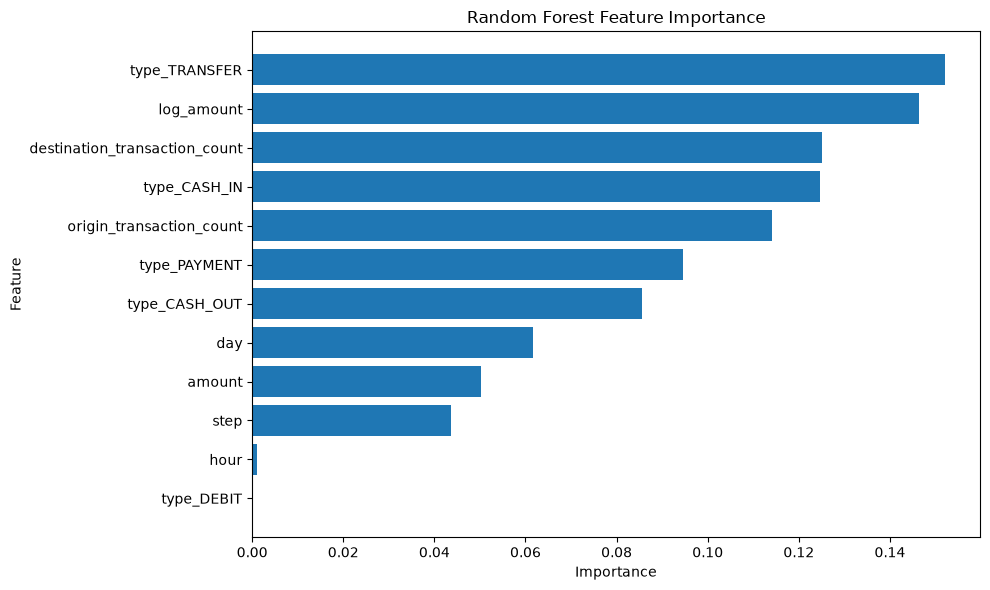

In [127]:
plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance_rf["Feature"],
    feature_importance_rf["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

In [128]:
print(X_train_encoded.columns.tolist())
print(len(X_train_encoded.columns))
print(len(rf_model.feature_importances_))

['step', 'amount', 'hour', 'day', 'origin_transaction_count', 'destination_transaction_count', 'log_amount', 'type_CASH_IN', 'type_CASH_OUT', 'type_DEBIT', 'type_PAYMENT', 'type_TRANSFER']
12
12


In [129]:
# Display top 10 most important features

top_features = feature_importance_rf.head(10)

top_features

,Feature,Importance
0,type_TRANSFER,0.152162
1,log_amount,0.146362
2,destination_transaction_count,0.125192
3,type_CASH_IN,0.124651
4,origin_transaction_count,0.114205
5,type_PAYMENT,0.094610
6,type_CASH_OUT,0.085671
7,day,0.061743
8,amount,0.050338
9,step,0.043628


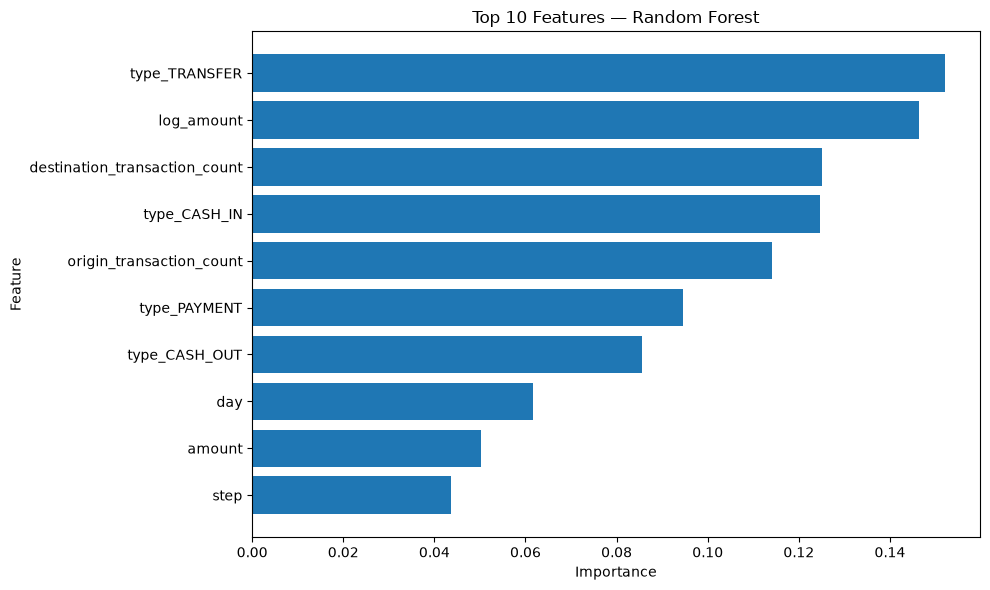

In [130]:
plt.figure(figsize=(10, 6))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Features — Random Forest")

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [131]:
print(xgb_model.get_params())

{'objective': 'binary:logistic', 'base_score': None, 'booster': None, 'callbacks': None, 'colsample_bylevel': None, 'colsample_bynode': None, 'colsample_bytree': None, 'device': None, 'early_stopping_rounds': None, 'enable_categorical': True, 'eval_metric': 'logloss', 'feature_types': None, 'feature_weights': None, 'gamma': None, 'grow_policy': None, 'importance_type': None, 'interaction_constraints': None, 'learning_rate': 0.1, 'max_bin': None, 'max_cat_threshold': None, 'max_cat_to_onehot': None, 'max_delta_step': None, 'max_depth': 6, 'max_leaves': None, 'min_child_weight': None, 'missing': nan, 'monotone_constraints': None, 'multi_strategy': None, 'n_estimators': 200, 'n_jobs': None, 'num_parallel_tree': None, 'random_state': 42, 'reg_alpha': None, 'reg_lambda': None, 'sampling_method': None, 'scale_pos_weight': None, 'subsample': None, 'tree_method': None, 'validate_parameters': None, 'verbosity': None}


In [132]:
# Convert categorical column to pandas category

X_train["type"] = X_train["type"].astype("category")
X_test["type"] = X_test["type"].astype("category")

In [133]:
# Make sure X_train and X_test have the same categories

all_categories = X_train["type"].cat.categories.union(
    X_test["type"].cat.categories
)

X_train["type"] = X_train["type"].cat.set_categories(all_categories)
X_test["type"] = X_test["type"].cat.set_categories(all_categories)

In [134]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    learning_rate=0.1,
    max_depth=6,
    n_estimators=200,
    random_state=42,
    enable_categorical=True
)

In [135]:
# Train XGBoost

xgb_model.fit(X_train, y_train)

,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [136]:
xgb_predictions = xgb_model.predict(X_test)

print(xgb_predictions[:10])

[0 0 0 0 0 0 0 0 0 0]


In [137]:
# Phase 11.2: XGBoost Feature Importance

feature_importance_xgb = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": xgb_model.feature_importances_
})

feature_importance_xgb = feature_importance_xgb.sort_values(
    by="Importance",
    ascending=False
)

feature_importance_xgb

,Feature,Importance
6,destination_transaction_count,0.310171
2,type,0.251949
1,amount,0.204371
0,step,0.101548
3,hour,0.089222
4,day,0.036189
7,log_amount,0.005174
5,origin_transaction_count,0.001378


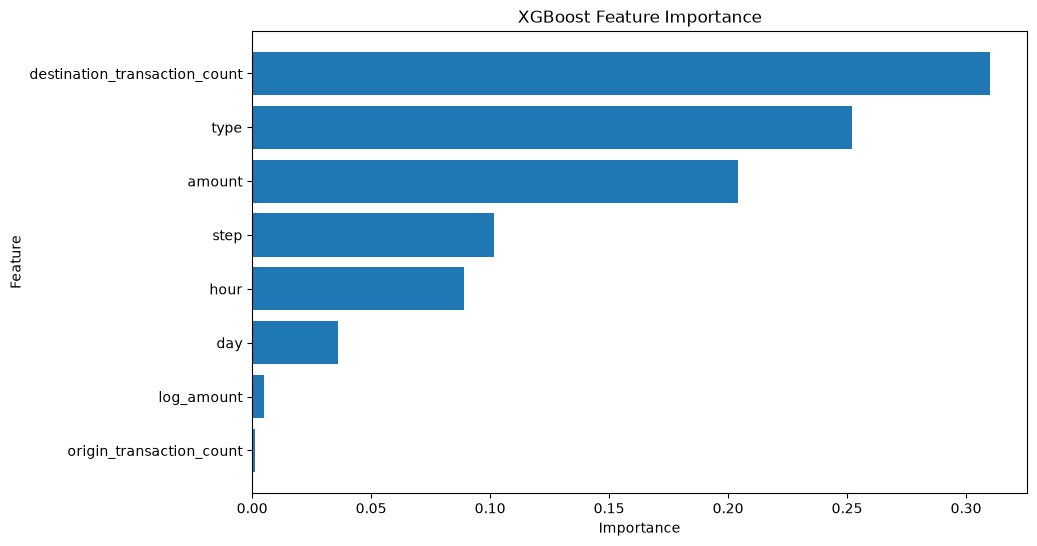

In [138]:
# XGBoost Feature Importance Plot

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance_xgb["Feature"],
    feature_importance_xgb["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("XGBoost Feature Importance")
plt.gca().invert_yaxis()

plt.show()

In [139]:
# Phase 11.3: Random Forest Feature Importance

feature_importance_rf.head(10)

,Feature,Importance
0,type_TRANSFER,0.152162
1,log_amount,0.146362
2,destination_transaction_count,0.125192
3,type_CASH_IN,0.124651
4,origin_transaction_count,0.114205
5,type_PAYMENT,0.094610
6,type_CASH_OUT,0.085671
7,day,0.061743
8,amount,0.050338
9,step,0.043628


In [140]:
feature_importance_xgb.head(10)

,Feature,Importance
6,destination_transaction_count,0.310171
2,type,0.251949
1,amount,0.204371
0,step,0.101548
3,hour,0.089222
4,day,0.036189
7,log_amount,0.005174
5,origin_transaction_count,0.001378


In [141]:
# Combine Random Forest and XGBoost feature importance

feature_comparison = feature_importance_rf.merge(
    feature_importance_xgb,
    on="Feature",
    suffixes=("_RF", "_XGB")
)

feature_comparison["Average_Importance"] = (
    feature_comparison["Importance_RF"] +
    feature_comparison["Importance_XGB"]
) / 2

feature_comparison = feature_comparison.sort_values(
    by="Average_Importance",
    ascending=False
)

feature_comparison

,Feature,Importance_RF,Importance_XGB,Average_Importance
1,destination_transaction_count,0.125192,0.310171,0.217681
4,amount,0.050338,0.204371,0.127355
0,log_amount,0.146362,0.005174,0.075768
5,step,0.043628,0.101548,0.072588
2,origin_transaction_count,0.114205,0.001378,0.057791
3,day,0.061743,0.036189,0.048966
6,hour,0.001161,0.089222,0.045191


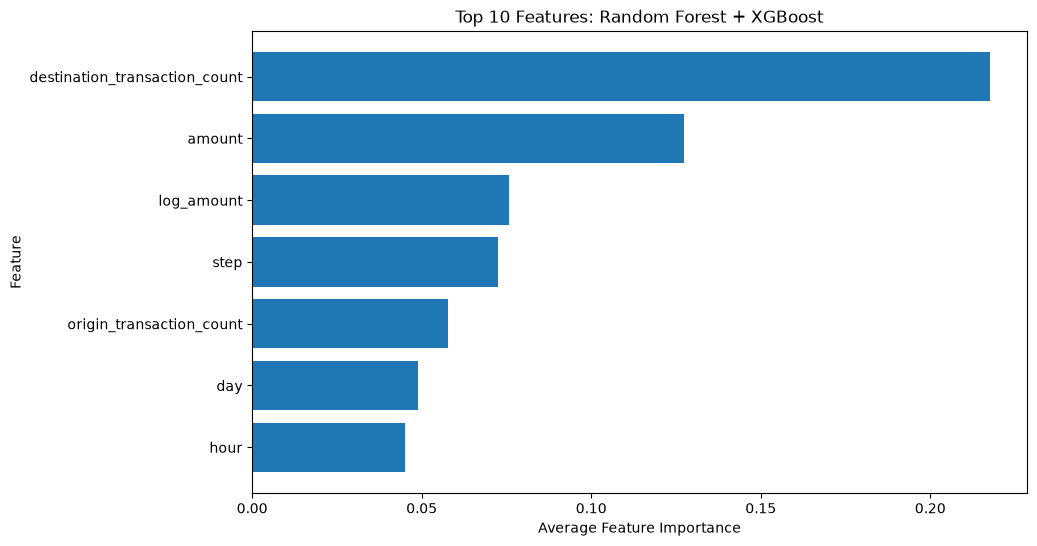

In [142]:
import matplotlib.pyplot as plt

top_features = feature_comparison.head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["Feature"],
    top_features["Average_Importance"]
)

plt.xlabel("Average Feature Importance")
plt.ylabel("Feature")
plt.title("Top 10 Features: Random Forest + XGBoost")

plt.gca().invert_yaxis()

plt.show()

In [143]:
# Phase 11.3: Compare Random Forest and XGBoost Feature Importance

feature_comparison = feature_importance_rf.merge(
    feature_importance_xgb,
    on="Feature",
    suffixes=("_RF", "_XGB")
)

feature_comparison = feature_comparison.sort_values(
    by="Importance_XGB",
    ascending=False
)

feature_comparison.head(15)

,Feature,Importance_RF,Importance_XGB
1,destination_transaction_count,0.125192,0.310171
4,amount,0.050338,0.204371
5,step,0.043628,0.101548
6,hour,0.001161,0.089222
3,day,0.061743,0.036189
0,log_amount,0.146362,0.005174
2,origin_transaction_count,0.114205,0.001378


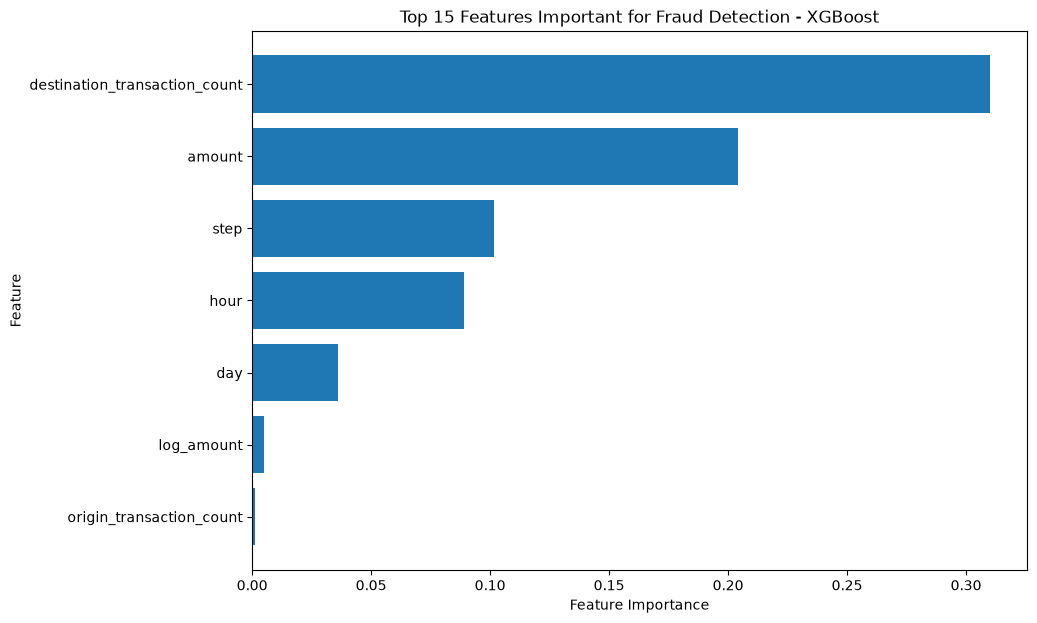

In [144]:
# Top 15 XGBoost Features

top_xgb_features = feature_comparison.head(15)

plt.figure(figsize=(10, 7))

plt.barh(
    top_xgb_features["Feature"],
    top_xgb_features["Importance_XGB"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 15 Features Important for Fraud Detection - XGBoost")

plt.gca().invert_yaxis()

plt.show()

## 7. Model Explainability with SHAP

In [145]:
!pip install shap

In [146]:
import shap

In [147]:
# Phase 11.5: SHAP Explainer

explainer = shap.TreeExplainer(xgb_model)

In [148]:
# Use a sample of the test data

X_test_sample = X_test.sample(
    n=min(5000, len(X_test)),
    random_state=42
)

shap_values = explainer.shap_values(X_test_sample)

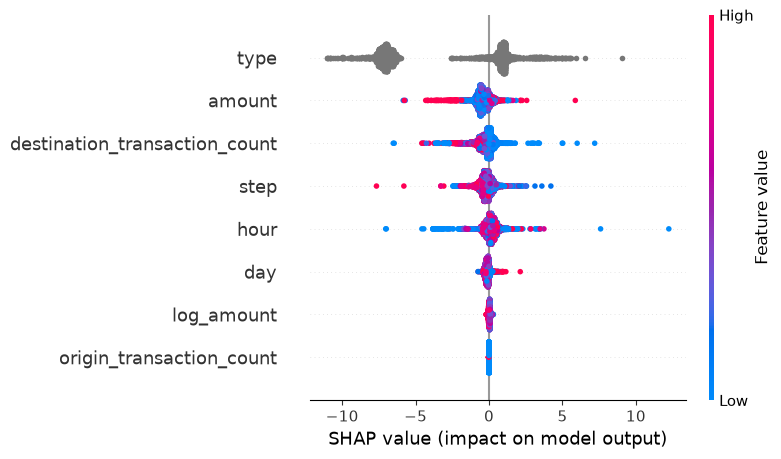

In [149]:
# SHAP Summary Plot

shap.summary_plot(
    shap_values,
    X_test_sample
)

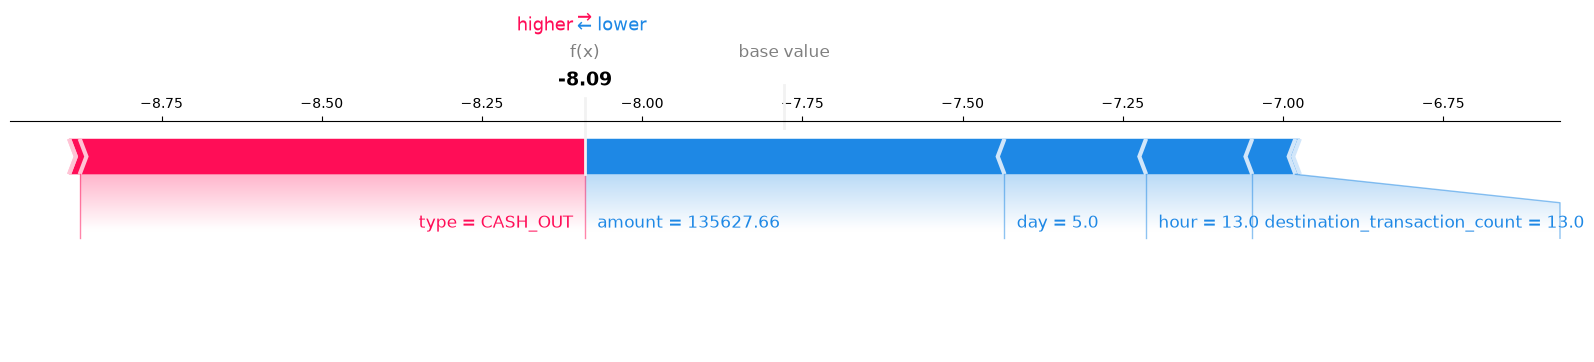

In [150]:
# Phase 11.6: Individual Transaction Explanation

transaction_index = 0

shap.force_plot(
    explainer.expected_value,
    shap_values[transaction_index],
    X_test_sample.iloc[transaction_index],
    matplotlib=True
)

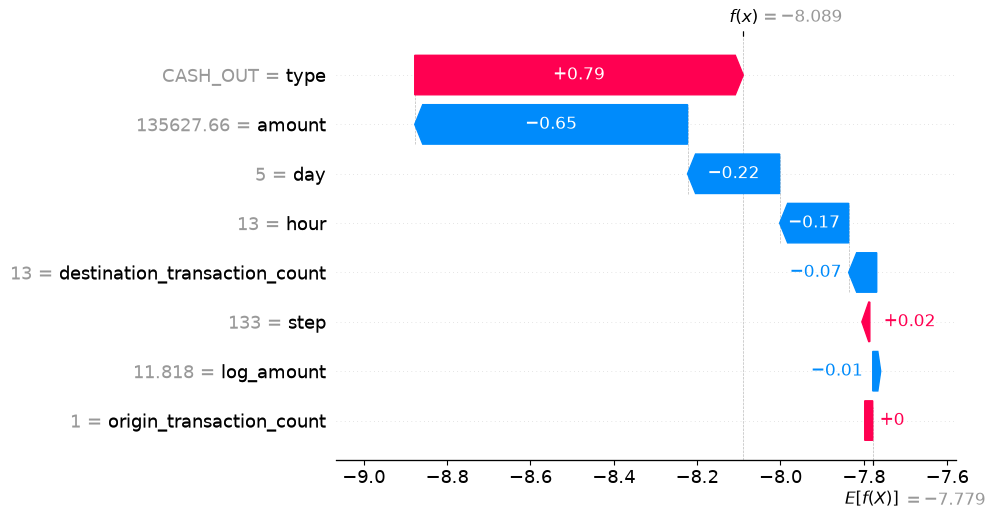

In [151]:
plt.figure(figsize=(12, 4))

shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[transaction_index],
        base_values=explainer.expected_value,
        data=X_test_sample.iloc[transaction_index],
        feature_names=X_test_sample.columns
    )
)

## 8. Fraud Prediction Function

In [152]:
# Phase 12.1: Fraud Prediction Function

def predict_fraud(transaction):
    
    # Convert transaction into DataFrame
    transaction_df = pd.DataFrame([transaction])
    
    # Make sure categorical column has the same category as training data
    transaction_df["type"] = pd.Categorical(
        transaction_df["type"],
        categories=X_train["type"].cat.categories
    )
    
    # Make prediction
    prediction = xgb_model.predict(transaction_df)[0]
    
    # Get fraud probability
    probability = xgb_model.predict_proba(transaction_df)[0][1]
    
    # Determine risk level
    if probability >= 0.75:
        risk_level = "High"
    elif probability >= 0.40:
        risk_level = "Medium"
    else:
        risk_level = "Low"
    
    # Display result
    print("Transaction Result")
    print("-------------------")
    
    if prediction == 1:
        print("Prediction: FRAUDULENT")
    else:
        print("Prediction: LEGITIMATE")
    
    print(f"Fraud Probability: {probability:.2%}")
    print(f"Risk Level: {risk_level}")

In [153]:
# Select one transaction from X_test

sample_transaction = X_test.iloc[0].to_dict()

print(sample_transaction)

{'step': 300, 'amount': 890577.21, 'type': 'TRANSFER', 'hour': 12, 'day': 12, 'origin_transaction_count': 1, 'destination_transaction_count': 7, 'log_amount': 13.69962620491873}


In [154]:
predict_fraud(sample_transaction)

Transaction Result
-------------------
Prediction: LEGITIMATE
Fraud Probability: 0.02%
Risk Level: Low


In [155]:
# Find an actual fraudulent transaction

fraud_indices = y_test[y_test == 1].index

fraud_transaction = X_test.loc[fraud_indices[0]].to_dict()

predict_fraud(fraud_transaction)

Transaction Result
-------------------
Prediction: FRAUDULENT
Fraud Probability: 100.00%
Risk Level: High


In [156]:
# Phase 12.4: Professional Fraud Detection System

def predict_fraud(transaction):
    
    # Convert transaction to DataFrame
    transaction_df = pd.DataFrame([transaction])
    
    # Match categorical type with training data
    transaction_df["type"] = pd.Categorical(
        transaction_df["type"],
        categories=X_train["type"].cat.categories
    )
    
    # Generate prediction
    prediction = xgb_model.predict(transaction_df)[0]
    
    # Fraud probability
    fraud_probability = xgb_model.predict_proba(transaction_df)[0][1]
    
    # Risk classification
    if fraud_probability >= 0.75:
        risk_level = "HIGH"
    elif fraud_probability >= 0.40:
        risk_level = "MEDIUM"
    else:
        risk_level = "LOW"
    
    # Transaction result
    if prediction == 1:
        result = "FRAUDULENT"
    else:
        result = "LEGITIMATE"
    
    # Display result
    print("=" * 45)
    print("        FRAUD DETECTION SYSTEM")
    print("=" * 45)
    print(f"Transaction Type    : {transaction['type']}")
    print(f"Prediction           : {result}")
    print(f"Fraud Probability    : {fraud_probability:.2%}")
    print(f"Risk Level           : {risk_level}")
    print("=" * 45)

In [157]:
predict_fraud(sample_transaction)

        FRAUD DETECTION SYSTEM
Transaction Type    : TRANSFER
Prediction           : LEGITIMATE
Fraud Probability    : 0.02%
Risk Level           : LOW


## 9. Key Insights & Conclusions

**Fraud is concentrated in two transaction types.** Every fraudulent
transaction in this dataset is a `TRANSFER` or `CASH_OUT`. A production
system could apply light-touch rules to `PAYMENT`/`CASH_IN`/`DEBIT` and
concentrate model scrutiny (and compute) on the two risky types.

**The dataset's built-in fraud flag is not useful on its own.**
`isFlaggedFraud` catches only 16 of 8,213 fraud cases.

**Amount is a strong, log-transformed signal**, and fraud transactions are
larger and more variable than legitimate ones.

**ROC-AUC can be misleading on imbalanced data.** Logistic Regression scored
well on ROC-AUC (0.93) but performed poorly by every other measure — always
report PR-AUC alongside ROC-AUC for rare-event problems like fraud.

**XGBoost is the best model here**: 91% precision, 50% recall, 0.98 ROC-AUC,
0.64 PR-AUC. It's the most trustworthy model when it flags a transaction,
though it still misses about half of actual fraud, so a production system
might lower the decision threshold to trade some precision for recall,
since missed fraud is typically costlier than a false alarm.

**Feature importance is consistent across models**: `destination_transaction_count`,
`amount`/`log_amount`, and transaction `type` (especially TRANSFER) are the
strongest predictors in both Random Forest and XGBoost. The two models
disagree on `origin_transaction_count` (important to RF, negligible to
XGBoost) — worth investigating further.

